# Final Exam 2 (Assignment) - HDDA
K-Means Clustering
Business Context:
This dataset represents retail banking customers, capturing their demographics (age), income level, account balance behavior (minimum and maximum balances), and relationship tenure with the bank.
It is typically used for customer segmentation to identify distinct customer groups for targeted products, risk profiling, and personalized banking strategies.

Dataset Description
* Age: Age of the customer in years.
* MonthlyIncome_EUR: Average monthly income of the customer, measured in euros.
* MinBal_EUR: Minimum account balance maintained by the customer during the observed period.
* MaxBal_EUR: Maximum account balance held by the customer during the observed period.
* Age_with_Bank: Number of years the customer has been associated with the bank (tenure).

Tasks
1. Import the dataset and identify analysis variables
1. Standardize the variables
1. Use the Elbow Method to determine the optimal number of clusters.
1. Perform K-Means clustering using the optimal number of clusters and assign cluster labels.
1. Compute cluster-wise summary statistics and interpret the clusters
1. Visualize the distribution of variables across clusters.

In [55]:
import pandas as pd

df = pd.read_csv("Final Exam 2 (Assignment) Data.csv")
df.head()

,Cust_Id,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank
0,100001,26,2315,217,4646,3
1,100002,24,2294,477,5541,1
2,100003,27,1891,265,5131,1
3,100004,31,2391,316,2136,1
4,100005,24,1708,426,4155,3


In [56]:
df.dtypes

Cust_Id              int64
Age                  int64
MonthlyIncome_EUR    int64
MinBal_EUR           int64
MaxBal_EUR           int64
Age_with_Bank        int64
dtype: object

In [57]:
df.describe()

,Cust_Id,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank
count,67775.000000,67775.000000,67775.000000,67775.000000,67775.000000,67775.000000
mean,140065.324353,43.073774,4479.320015,3097.492837,24126.518362,9.392210
std,21474.444496,13.377097,1813.920141,2989.505554,20350.453491,6.527579
min,100001.000000,23.000000,1034.000000,0.000000,0.000000,0.000000
25%,123115.500000,31.000000,3195.000000,795.000000,8020.500000,4.000000
50%,140086.000000,42.000000,4170.000000,1875.000000,17014.000000,9.000000
75%,157029.500000,54.000000,5800.000000,4385.000000,34662.000000,14.000000
max,180000.000000,66.000000,10478.000000,15910.000000,119045.000000,27.000000


In [58]:
df.isnull().sum()

Cust_Id              0
Age                  0
MonthlyIncome_EUR    0
MinBal_EUR           0
MaxBal_EUR           0
Age_with_Bank        0
dtype: int64

## Initial Understanding of the Variables

This is an unsupervised learning problem focused on customer segmentation. There is no target variable. Instead, the goal is to group customers with similar demographic and banking behavior into meaningful clusters.

The variables that will be used for clustering are:

- `Age`
- `MonthlyIncome_EUR`
- `MinBal_EUR`
- `MaxBal_EUR`
- `Age_with_Bank`

`Cust_Id` is only an identifier and should not be included in the clustering process.

In [59]:
cluster_features = ["Age", "MonthlyIncome_EUR", "MinBal_EUR", "MaxBal_EUR", "Age_with_Bank"]
cluster_data = df[cluster_features]

cluster_data.head()

,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank
0,26,2315,217,4646,3
1,24,2294,477,5541,1
2,27,1891,265,5131,1
3,31,2391,316,2136,1
4,24,1708,426,4155,3


These variables capture a combination of demographic characteristics, financial capacity, account balance behavior, and relationship tenure. Together, they provide a practical basis for identifying distinct customer segments.

In [60]:
feature_summary = pd.DataFrame({
    "Variable": cluster_features,
    "Mean": cluster_data.mean().round(2).values,
    "Std_Dev": cluster_data.std().round(2).values,
    "Min": cluster_data.min().round(2).values,
    "Max": cluster_data.max().round(2).values
})

feature_summary

,Variable,Mean,Std_Dev,Min,Max
0,Age,43.07,13.38,23,66
1,MonthlyIncome_EUR,4479.32,1813.92,1034,10478
2,MinBal_EUR,3097.49,2989.51,0,15910
3,MaxBal_EUR,24126.52,20350.45,0,119045
4,Age_with_Bank,9.39,6.53,0,27


The summary statistics show that the variables are on very different scales. Income and balance values are much larger than age and tenure, which means standardization is required before applying K-Means clustering.

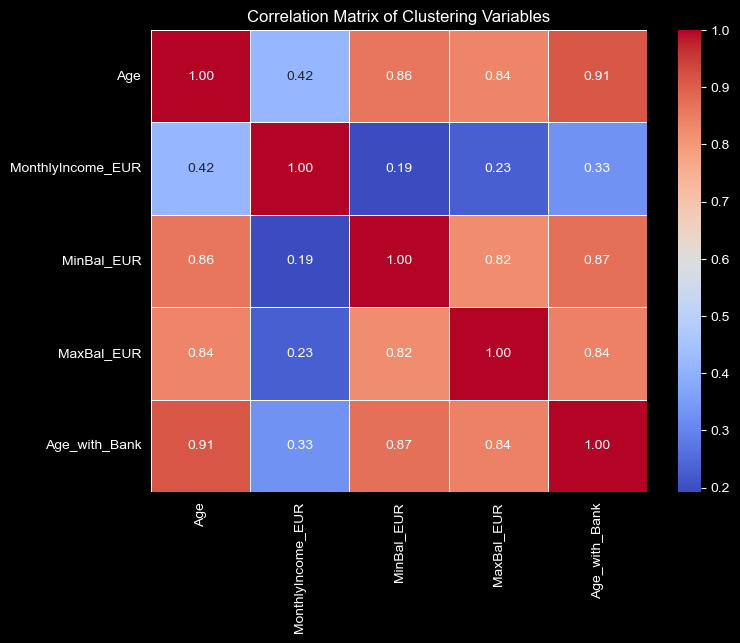

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = cluster_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Clustering Variables")
plt.show()

The correlation matrix gives an initial view of how the banking variables move together. This is useful for understanding whether some dimensions may reflect similar customer behavior patterns.

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

scaled_df = pd.DataFrame(scaled_data, columns=cluster_features)
scaled_df.describe().round(2)

,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank
count,67775.00,67775.00,67775.00,67775.00,67775.00
mean,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.50,-1.90,-1.04,-1.19,-1.44
25%,-0.90,-0.71,-0.77,-0.79,-0.83
50%,-0.08,-0.17,-0.41,-0.35,-0.06
75%,0.82,0.73,0.43,0.52,0.71
max,1.71,3.31,4.29,4.66,2.70


After standardization, all clustering variables are on a comparable scale. This is the appropriate input for K-Means clustering.

## Elbow Method

The Elbow Method helps determine the number of clusters by plotting the within-cluster sum of squares (WCSS) for different values of `k`. The preferred number of clusters is typically located at the point where the reduction in WCSS begins to slow down noticeably.

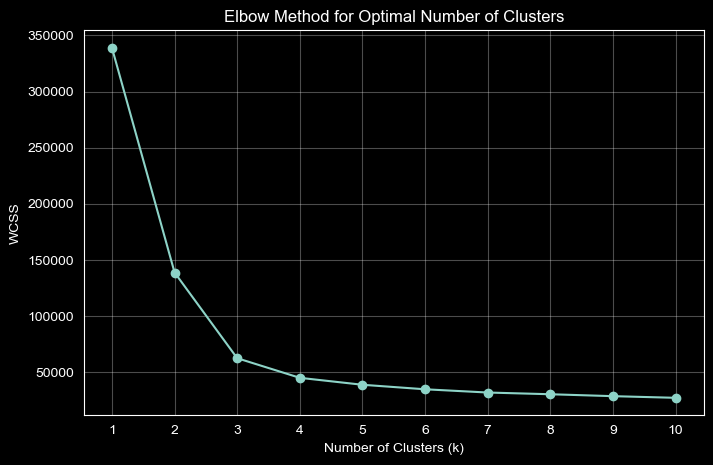

In [63]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

The elbow plot should be examined to identify the value of `k` after which the marginal improvement becomes smaller. That point represents a reasonable balance between model simplicity and cluster separation.

In [64]:
elbow_table = pd.DataFrame({
    "k": list(k_range),
    "WCSS": wcss
})

elbow_table

,k,WCSS
0,1,338875.000000
1,2,138917.524353
2,3,62685.656873
3,4,45234.161971
4,5,39060.389992
5,6,35044.727324
6,7,32152.173617
7,8,30627.793221
8,9,28922.815360
9,10,27449.748195


To complement the elbow method, cluster quality is also assessed with the silhouette score. Higher values indicate better separation between clusters and better cohesion within clusters.

The full silhouette calculation was not computationally practical for this dataset in the notebook environment. For that reason, the silhouette score is estimated on a representative sample of observations, and the analysis is limited to `k = 2` through `k = 5`, since the elbow plot already points to `k = 3` as the main candidate.

In [65]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
silhouette_k_range = range(2, 6)
silhouette_sample_size = 5000

for k in silhouette_k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    silhouette_scores.append(
        silhouette_score(
            scaled_data,
            labels,
            sample_size=silhouette_sample_size,
            random_state=42
        )
    )

silhouette_table = pd.DataFrame({
    "k": list(silhouette_k_range),
    "Silhouette_Score": silhouette_scores
})

silhouette_table

,k,Silhouette_Score
0,2,0.531536
1,3,0.584457
2,4,0.536021
3,5,0.483478


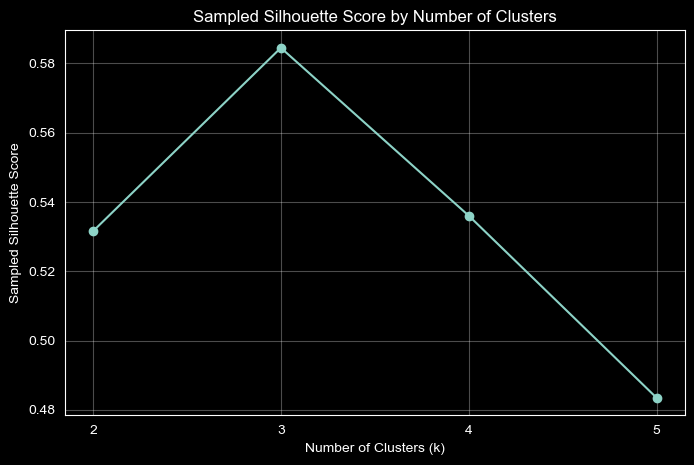

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(silhouette_k_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sampled Silhouette Score")
plt.title("Sampled Silhouette Score by Number of Clusters")
plt.xticks(silhouette_k_range)
plt.grid(alpha=0.3)
plt.show()

The elbow plot remains the main criterion for choosing the number of clusters, and the sampled silhouette score is used as a supporting check. If `k = 3` shows the elbow and also a competitive sampled silhouette score, then it is a reasonable final choice for K-Means.

## K-Means Clustering

Based on the elbow method and the sampled silhouette review, the clustering model is fitted with `k = 3`.

In [67]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters
df.head()

,Cust_Id,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank,Cluster
0,100001,26,2315,217,4646,3,0
1,100002,24,2294,477,5541,1,0
2,100003,27,1891,265,5131,1,0
3,100004,31,2391,316,2136,1,0
4,100005,24,1708,426,4155,3,0


In [68]:
df["Cluster"].value_counts().sort_index()

Cluster
0    33770
1    13936
2    20069
Name: count, dtype: int64

The cluster counts show how customers are distributed across the segments. A very uneven distribution may suggest that one cluster represents a broad mainstream group, while smaller clusters may capture more specialized customer profiles.

## Cluster-Wise Summary Statistics

Cluster profiling should be performed using the original, unscaled variables. This is important because business interpretation is easier and more meaningful on the original measurement scale.

In [69]:
cluster_profile = df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["Count"] = df.groupby("Cluster").size()
cluster_profile

,Age,MonthlyIncome_EUR,MinBal_EUR,MaxBal_EUR,Age_with_Bank,Count
Cluster,,,,,,
0,31.28,3378.28,833.88,8946.76,3.96,33770
1,62.43,3802.25,8023.65,55355.37,19.51,13936
2,49.48,6802.21,3485.71,27983.97,11.51,20069


The cluster profile table summarizes the average characteristics of each customer segment. These values can be used to describe the clusters in terms of age, income, balance behavior, and banking tenure.

## Visual Comparison of Clusters

To better understand the segments, it is useful to compare the average values of the original variables across clusters.

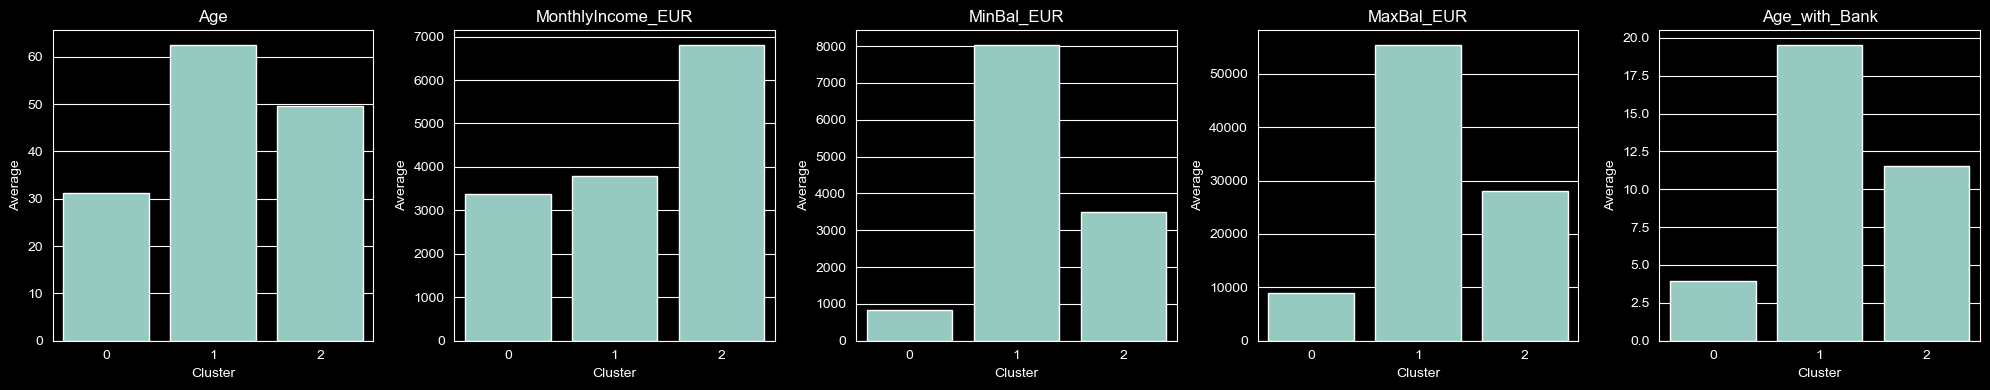

In [70]:
fig, axes = plt.subplots(1, len(cluster_features), figsize=(20, 4))

for ax, col in zip(axes, cluster_features):
    sns.barplot(x=cluster_profile.index, y=cluster_profile[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Average")

plt.tight_layout()
plt.show()

These plots help reveal how the clusters differ across customer characteristics and financial behavior. Distinct patterns across the variables indicate that the clustering solution is capturing meaningful customer segments.

## Cluster Interpretation

- `Cluster 0`: younger customers with the lowest income, lower balances, and the shortest relationship with the bank. This is the broad mass-market segment.
- `Cluster 1`: older customers with the longest banking tenure and the highest balances, despite only moderate income. This looks like a mature, asset-rich segment.
- `Cluster 2`: middle-aged customers with the highest income and intermediate balances and tenure. This appears to be a higher-earning, established segment.

## Heatmap of Standardized Cluster Differences

The heatmap below uses the K-Means centroids on the standardized scale. Positive values indicate that the cluster is above the overall average for that variable, while negative values indicate that it is below the overall average.

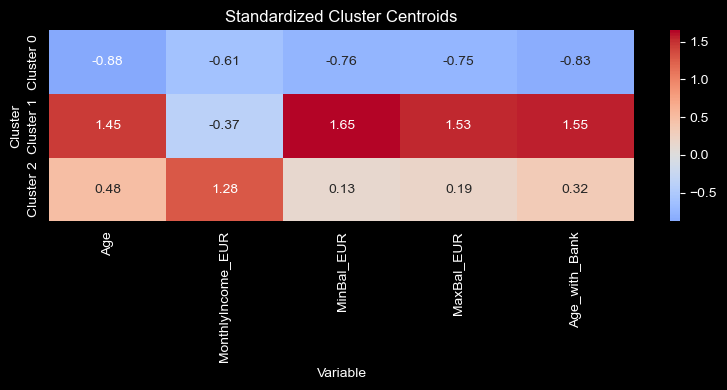

In [71]:
centroid_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features,
    index=[f"Cluster {i}" for i in range(optimal_k)]
)

plt.figure(figsize=(8, 4))
sns.heatmap(centroid_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Standardized Cluster Centroids")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Distribution of Variables Across Clusters

Boxplots are more informative than mean bar charts for the assignment requirement because they show the distribution, spread, and overlap of each variable across clusters.

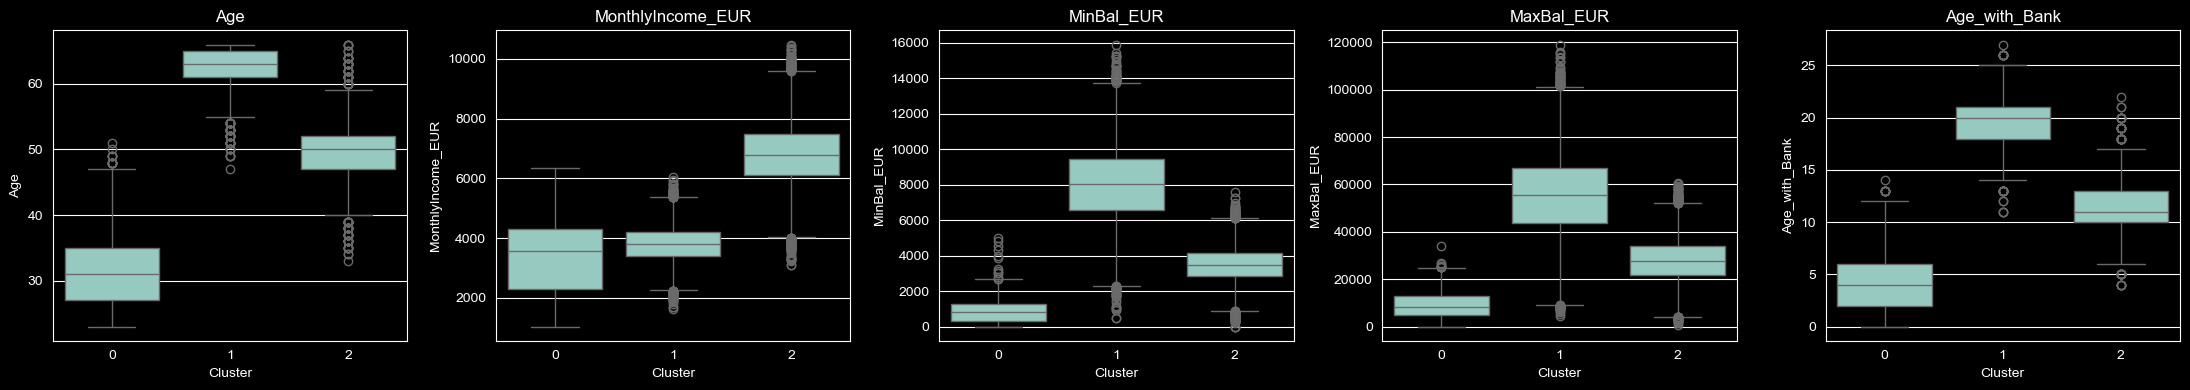

In [72]:
fig, axes = plt.subplots(1, len(cluster_features), figsize=(22, 4))

for ax, col in zip(axes, cluster_features):
    sns.boxplot(data=df, x="Cluster", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## PCA View of Cluster Separation

A two-dimensional PCA projection provides a compact visual check of how the clusters separate in reduced feature space.

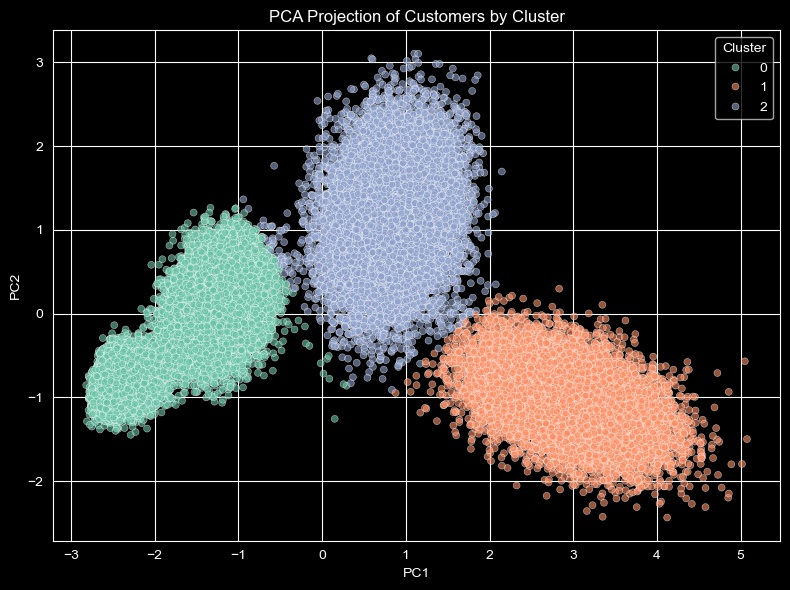

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "Cluster": df["Cluster"]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", alpha=0.6, s=25)
plt.title("PCA Projection of Customers by Cluster")
plt.tight_layout()
plt.show()

Taken together, the cluster profile table, centroid heatmap, boxplots, and PCA projection provide a consistent view of the customer segments. These results support the use of `k = 3` and show that the clusters differ in age, income, balance behavior, and relationship tenure.